# 1D RM-synthesis weighting

RM-synthesis is a Fourier transform from $\lambda^2$ to Faraday depth $\phi$, so
the RMSF (the response function, analogous to the interferometric dirty beam) is
the Fourier transform of the per-channel *weights* over $\lambda^2$. The channel
sampling in $\lambda^2$ is fixed by the band, but the weights are ours to choose,
exactly like uv weighting in aperture-synthesis imaging.

`rm-lite` provides the interferometric weighting schemes:

| weight_type | definition | interferometric analogue |
| --- | --- | --- |
| `variance` / `natural` | $1/\sigma^2$ | natural (max sensitivity) |
| `uniform` | equal per channel | (no weighting) |
| `uniform_lsq` | equal per $\lambda^2$ cell | uniform (max resolution) |
| `briggs` | robust interpolation | Briggs / robust |

`briggs` spans the range with a single `robust` knob (large positive $\to$
`natural`, large negative $\to$ `uniform_lsq`).

This notebook has two parts. **Part A** builds the $\lambda^2$-grid weighting
step by step on ASKAP **RACS** coverage (sub-bands separated by gaps, so the grid
and its occupancy are easy to see). **Part B** compares every scheme on
contiguous **GMIMS-DRAGONS** coverage, where the weighting types differ most.
Every claim below is checked with an `assert`.

In [1]:
from __future__ import annotations

import logging

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from astropy.visualization import quantity_support
from numpy.typing import NDArray
from rm_lite.tools_1d import rmclean, rmsynth
from rm_lite.utils.logging import quiet_logs
from rm_lite.utils.synthesis import (
    FDFOptions,
    briggs_weight,
    compute_rmsynth_params,
    freq_to_lambda2,
    inverse_rmsynth_nufft,
    uniform_lsq_weight,
)

plt.rcParams["figure.dpi"] = 150
_ = quantity_support()
rng = np.random.default_rng(42)

# rm_lite logs each synth/clean run; `with quiet_logs(logging.ERROR):` around the
# runs below keeps the notebook quiet.

# Distinct styles so overlapping traces (e.g. variance and uniform) stay visible.
LINE_STYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 2))]
MARKERS = [".", "x", "+", "^", "s", "d"]

A Burn slab gives the Faraday-thick source; a helper measures the RMSF FWHM.

In [2]:
def faraday_slab_spectrum(
    lambda_sq_arr_m2: NDArray[np.float64],
    frac_pol: float,
    psi0_deg: float,
    rm_radm2: float,
    delta_rm_radm2: float,
) -> NDArray[np.complex128]:
    """Burn slab: a Faraday-thick component of thickness delta_rm."""
    return (
        frac_pol
        * np.exp(2j * (np.deg2rad(psi0_deg) + rm_radm2 * lambda_sq_arr_m2))
        * np.sinc(delta_rm_radm2 * lambda_sq_arr_m2 / np.pi)
    ).astype(np.complex128)


def fwhm_from_curve(phi: NDArray[np.float64], amp: NDArray[np.float64]) -> float:
    """FWHM of the main lobe from the half-maximum crossings (linear interp)."""
    amp = amp / amp.max()
    peak = int(np.argmax(amp))

    def cross(idxs: range) -> float:
        prev = peak
        for i in idxs:
            if amp[i] < 0.5:
                frac = (0.5 - amp[prev]) / (amp[i] - amp[prev])
                return float(phi[prev] + frac * (phi[i] - phi[prev]))
            prev = i
        return float(phi[idxs[-1]])

    return cross(range(peak + 1, len(amp))) - cross(range(peak - 1, -1, -1))

## Part A - building the grid weighting (RACS-all)

ASKAP RACS observes in separated sub-bands (low/mid/high). That gapped coverage
is ideal for showing how `uniform_lsq`/`briggs` are built: lay a virtual
$\lambda^2$ grid, count the per-cell occupancy, and weight each channel by the
inverse local density. (Channel counts are downsampled here for speed.)

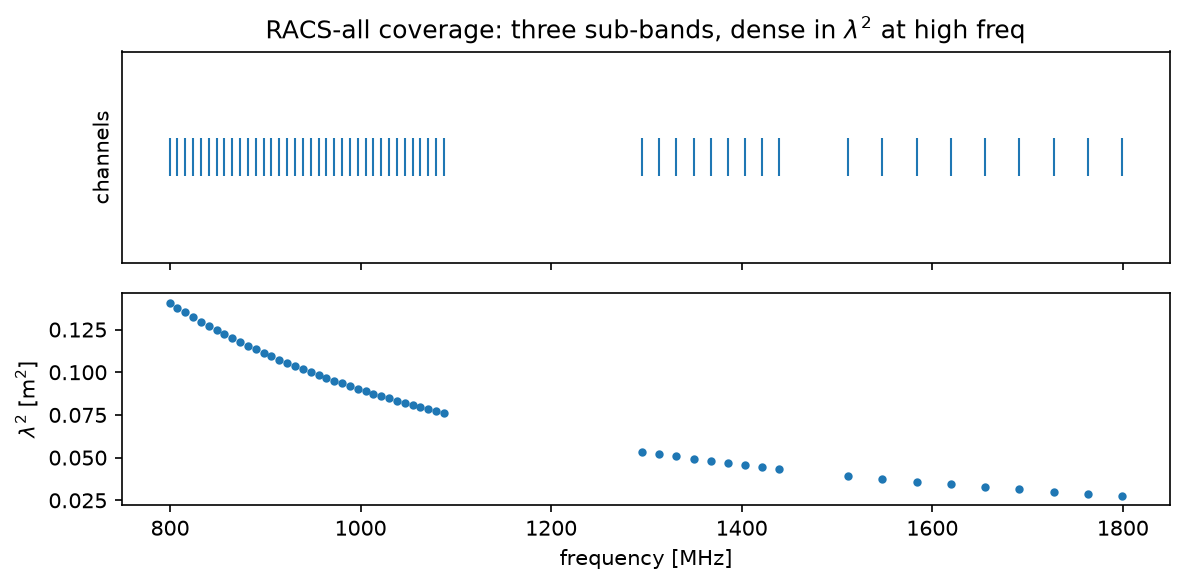

In [3]:
# ASKAP RACS-all: low/mid/high sub-bands (channel counts downsampled for speed).
bw_low, bw_mid, bw_high = 288, 144, 288
low = np.linspace(943.5 - bw_low / 2, 943.5 + bw_low / 2, 36) * u.MHz
mid = np.linspace(1367.5 - bw_mid / 2, 1367.5 + bw_mid / 2, 9) * u.MHz
high = np.linspace(1655.5 - bw_high / 2, 1655.5 + bw_high / 2, 9) * u.MHz
freq_racs = np.concatenate([low, mid, high]).to(u.Hz).value
lam2_racs = freq_to_lambda2(freq_racs)

# Sampling in both frequency (top) and the lambda^2 it maps to (bottom): three
# sub-bands separated by gaps, and lambda^2 bunches up at the high-frequency end.
fig, (axf, axl) = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
axf.plot(freq_racs / 1e6, np.ones_like(freq_racs), "|", ms=18)
axf.set(yticks=[], ylabel="channels")
axl.plot(freq_racs / 1e6, lam2_racs, ".")
axl.set(xlabel="frequency [MHz]", ylabel=r"$\lambda^2$ [m$^2$]")
axf.set_title("RACS-all coverage: three sub-bands, dense in $\\lambda^2$ at high freq")
fig.tight_layout()

### The virtual $\lambda^2$ grid

The resolution cell is $\mathrm{cell} = \sqrt{3}/\phi_\mathrm{max}$ (the RMSF
cell). Each channel is snapped to a cell index; the gaps between sub-bands leave
empty cells.

[Text(0.5, 0, '$\\lambda^2$ [m$^2$]'),
 Text(0, 0.5, 'virtual cell index'),
 Text(0.5, 1.0, 'each channel snapped to a virtual $\\lambda^2$ cell')]

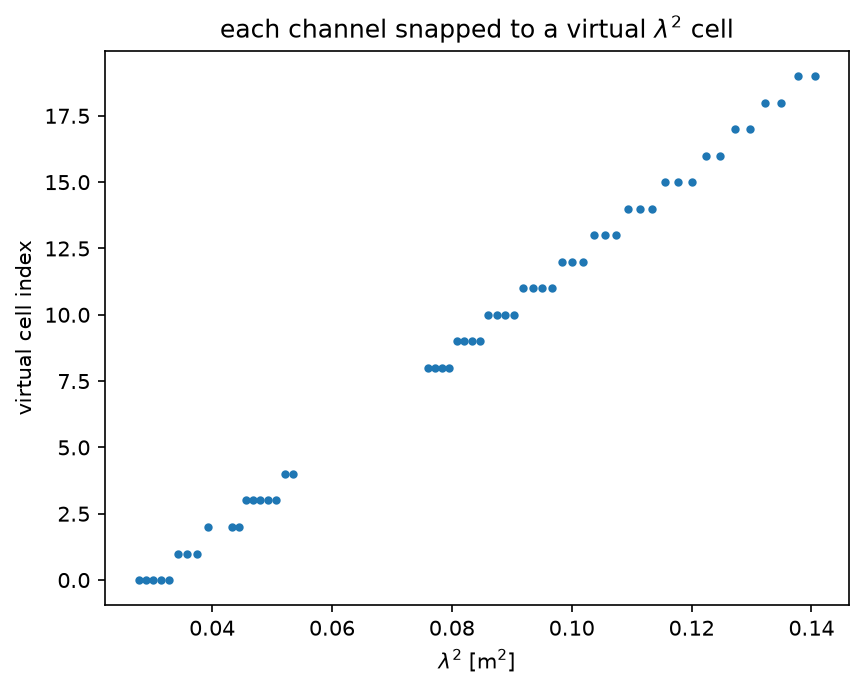

In [4]:
phi_max = 300.0
cell = np.sqrt(3.0) / phi_max
cell_idx = np.floor((lam2_racs - lam2_racs.min()) / cell).astype(int)

fig, ax = plt.subplots()
ax.plot(lam2_racs, cell_idx, ".")
ax.set(
    xlabel=r"$\lambda^2$ [m$^2$]",
    ylabel="virtual cell index",
    title="each channel snapped to a virtual $\\lambda^2$ cell",
)

### Occupancy $\to$ weights

`uniform_lsq` weight $= $ natural weight $/$ local density, where the density is
the total natural weight in a channel's cell over the cell width. So each
*occupied* cell contributes equally, and channels sharing a cell get one weight.
`briggs` blends this with the natural weight via the `robust` knob. With flat
noise the natural weight is 1, so `uniform_lsq` reduces to $1/N_\mathrm{cell}$.

within-cell uniform + each occupied cell contributes equally: OK


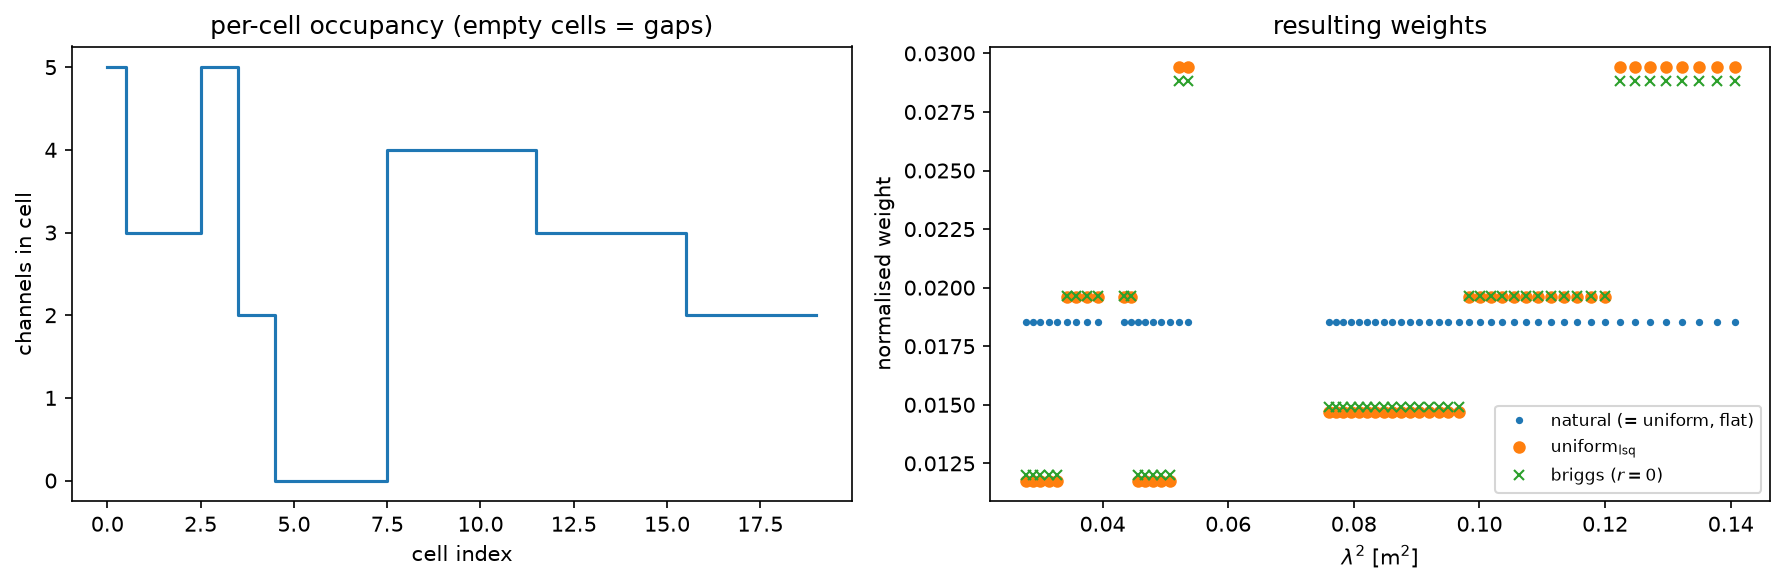

In [5]:
natural = np.ones_like(lam2_racs)  # flat noise -> natural weight = 1
count = np.bincount(cell_idx)  # channels per cell

w_uniform_lsq = uniform_lsq_weight(lam2_racs, natural, cell)
w_briggs0 = briggs_weight(lam2_racs, natural, 0.0, cell)

fig, (axo, axw) = plt.subplots(1, 2, figsize=(12, 4))
axo.step(np.arange(len(count)), count, where="mid")
axo.set(
    xlabel="cell index",
    ylabel="channels in cell",
    title="per-cell occupancy (empty cells = gaps)",
)
for w, lbl, mk in [
    (natural, "natural (= uniform, flat)", "."),
    (w_uniform_lsq, r"uniform$_\mathrm{lsq}$", "o"),
    (w_briggs0, r"briggs ($r=0$)", "x"),
]:
    axw.plot(lam2_racs, w / np.nansum(w), mk, ms=5, ls="none", label=lbl)
axw.set(
    xlabel=r"$\lambda^2$ [m$^2$]", ylabel="normalised weight", title="resulting weights"
)
axw.legend(fontsize="small")
fig.tight_layout()

# Checks: channels in a cell share one weight (no single-channel jump within a
# cell), and each occupied cell contributes equal total weight.
for c in np.unique(cell_idx):
    in_cell = w_uniform_lsq[cell_idx == c]
    np.testing.assert_allclose(in_cell, in_cell[0], rtol=1e-12)
totals = np.array([w_uniform_lsq[cell_idx == c].sum() for c in np.unique(cell_idx)])
np.testing.assert_allclose(totals, totals[0], rtol=1e-12)
print("within-cell uniform + each occupied cell contributes equally: OK")

## Part B - comparison on GMIMS-DRAGONS

Now switch to contiguous **GMIMS-DRAGONS** coverage (350-1030 MHz). The wide
low-frequency band gives the weighting real leverage, so `uniform_lsq` narrows
the RMSF substantially. We inject a Faraday-thick Burn slab (thickness
10 rad/m$^2$ at 30 rad/m$^2$), add noise, and compare the schemes.

[Text(0.5, 0, '$\\nu$ / $\\mathrm{Hz}$'), Text(0, 0.5, 'Fractional flux')]

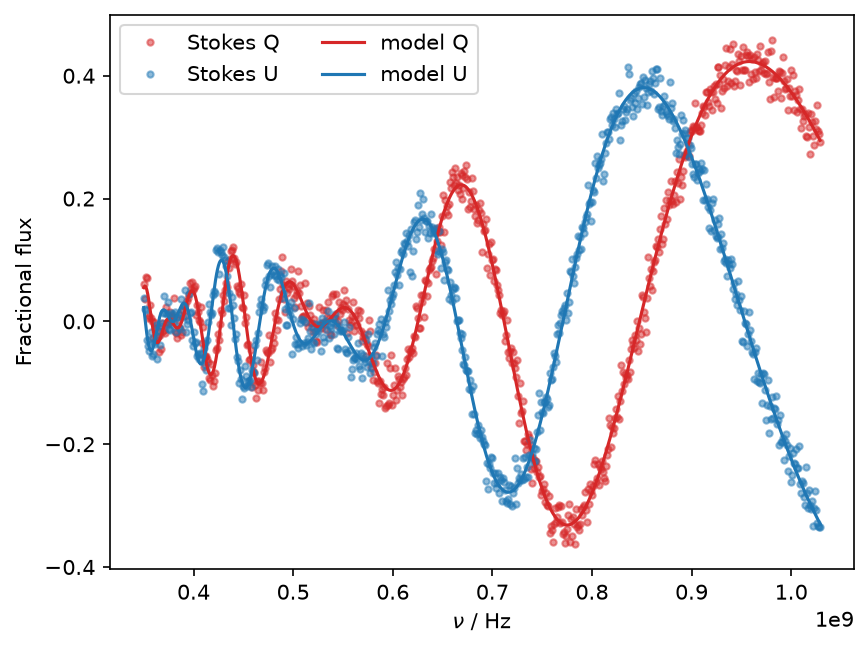

In [6]:
freq_hz = (np.arange(350, 1030, 1) * u.MHz).to(u.Hz).value
lambda_sq = freq_to_lambda2(freq_hz)

rm_radm2 = 30.0
delta_rm_radm2 = 10.0
frac_pol = 0.5
psi0_deg = 10.0
model_kw = {
    "frac_pol": frac_pol,
    "psi0_deg": psi0_deg,
    "rm_radm2": rm_radm2,
    "delta_rm_radm2": delta_rm_radm2,
}
complex_model = faraday_slab_spectrum(lambda_sq, **model_kw)
rms_noise = 0.02
complex_noisy = (
    complex_model
    + rng.normal(0, rms_noise, freq_hz.size)
    + 1j * rng.normal(0, rms_noise, freq_hz.size)
).astype(np.complex128)
complex_err = np.ones_like(complex_noisy) * (rms_noise + rms_noise * 1j)

fig, ax = plt.subplots()
ax.plot(freq_hz, complex_noisy.real, ".", color="tab:red", alpha=0.5, label="Stokes Q")
ax.plot(freq_hz, complex_noisy.imag, ".", color="tab:blue", alpha=0.5, label="Stokes U")
ax.plot(freq_hz, complex_model.real, color="tab:red", label="model Q")
ax.plot(freq_hz, complex_model.imag, color="tab:blue", label="model U")
ax.legend(ncol=2)
ax.set(xlabel=rf"$\nu$ / {u.Hz:latex_inline}", ylabel="Fractional flux")

A helper runs RM-synthesis for one weighting and returns the weights, RMSF and
FDF. `compute_rmsynth_params` exposes the actual per-channel weight array.

In [7]:
def run_weighting(**kw: object) -> dict:
    """Run RM-synthesis for one weighting; collect weights, RMSF, FDF, synth."""
    opts = FDFOptions(n_samples=50, phi_max_radm2=300.0, **kw)  # type: ignore[arg-type]
    params = compute_rmsynth_params(freq_hz, complex_noisy, complex_err, opts)
    synth = rmsynth.run_rmsynth(
        freq_arr_hz=freq_hz,
        complex_pol_arr=complex_noisy,
        complex_pol_error=complex_err,
        n_samples=50,
        phi_max_radm2=300.0,
        **kw,  # type: ignore[arg-type]
    )
    fdf_arrs, rmsf_arrs = synth[1], synth[2]
    phi2 = rmsf_arrs["phi2_arr_radm2"].to_numpy()
    rmsf = np.abs(rmsf_arrs["rmsf_complex_arr"].to_numpy().astype(complex))
    return {
        "synth": synth,
        "weight": params.weight_arr,
        "phi": fdf_arrs["phi_arr_radm2"].to_numpy(),
        "fdf": np.abs(fdf_arrs["fdf_dirty_complex_arr"].to_numpy().astype(complex)),
        "phi2": phi2,
        "rmsf": rmsf,
        "fwhm": fwhm_from_curve(phi2, rmsf),
    }

## Run every weighting

We run all the schemes once and reuse them in every plot below: `variance` and
`uniform` (which coincide here because the noise is flat), `uniform_lsq`, and
`briggs` at `robust` $= -1, 0, +1$.

In [8]:
weightings = {
    "variance": {"weight_type": "variance"},
    "uniform": {"weight_type": "uniform"},
    "uniform_lsq": {"weight_type": "uniform_lsq"},
    "briggs r=-1": {"weight_type": "briggs", "robust": -1.0},
    "briggs r=0": {"weight_type": "briggs", "robust": 0.0},
    "briggs r=+1": {"weight_type": "briggs", "robust": 1.0},
}
# TeX display labels (keys above stay plain for indexing/tables).
tex_label = {
    "variance": "variance",
    "uniform": "uniform",
    "uniform_lsq": r"uniform$_\mathrm{lsq}$",
    "briggs r=-1": r"briggs ($r=-1$)",
    "briggs r=0": r"briggs ($r=0$)",
    "briggs r=+1": r"briggs ($r=+1$)",
}
with quiet_logs(logging.ERROR):
    results = {label: run_weighting(**kw) for label, kw in weightings.items()}

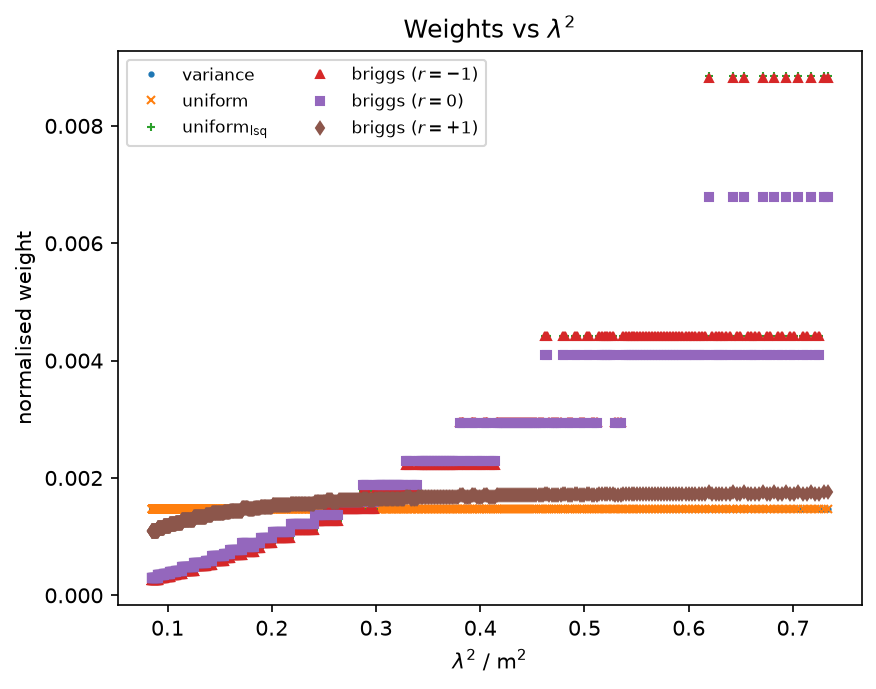

In [9]:
# Weights vs lambda^2: uniform_lsq / low-robust up-weight the sparse large-lambda^2 end.
fig, ax = plt.subplots()
for (label, res), marker in zip(results.items(), MARKERS, strict=False):
    w = res["weight"] / np.nansum(res["weight"])
    ax.plot(lambda_sq, w, marker, ms=4, ls="none", label=tex_label[label])
ax.set(
    xlabel=rf"$\lambda^2$ / {u.m**2:latex_inline}",
    ylabel="normalised weight",
    title=r"Weights vs $\lambda^2$",
)
ax.legend(ncol=2, fontsize="small")

### RMSF

`uniform_lsq` (and low-robust `briggs`) narrow the RMSF main lobe; `variance`,
`uniform` and high-robust `briggs` are the widest, most sensitive response. Over
this wide contiguous band the effect is sizeable: `uniform_lsq` narrows the FWHM
by roughly a third. The `briggs` points run monotonically between the endpoints
(`natural` widest, `uniform_lsq` narrowest).

weighting,rmsf_fwhm_radm2
str,f64
"""variance""",8.535859
"""uniform""",8.535859
"""uniform_lsq""",5.81236
"""briggs r=-1""",5.812971
"""briggs r=0""",5.870325
"""briggs r=+1""",7.467687


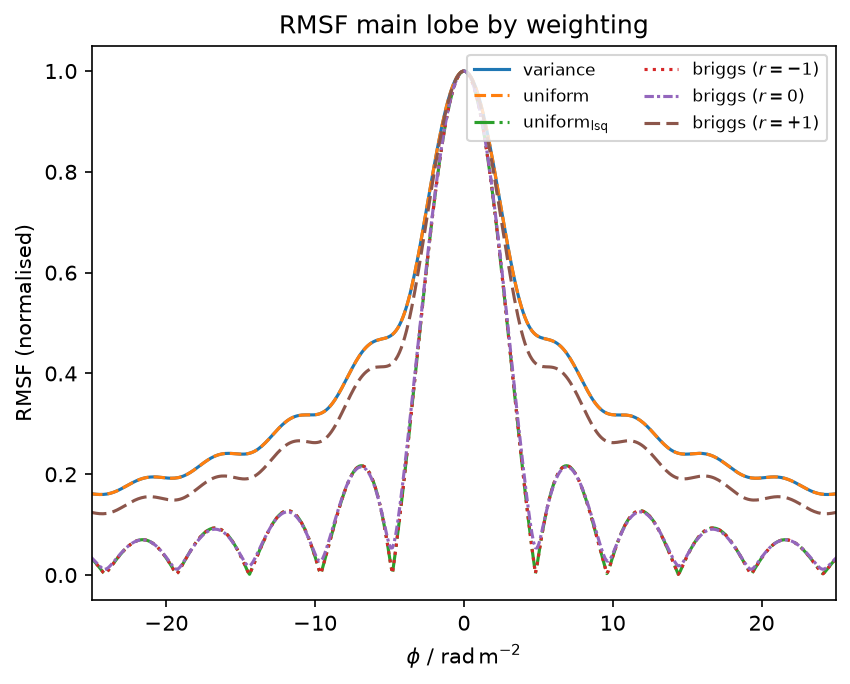

In [10]:
fig, ax = plt.subplots()
for (label, res), ls in zip(results.items(), LINE_STYLES, strict=False):
    ax.plot(res["phi2"], res["rmsf"] / res["rmsf"].max(), ls=ls, label=tex_label[label])
ax.set(
    xlim=(-25, 25),
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="RMSF (normalised)",
    title="RMSF main lobe by weighting",
)
ax.legend(ncol=2, fontsize="small")

fwhm = {label: res["fwhm"] for label, res in results.items()}
assert abs(fwhm["variance"] - fwhm["uniform"]) < 0.5, "flat noise: natural == uniform"
narrowing = (fwhm["uniform"] - fwhm["uniform_lsq"]) / fwhm["uniform"]
assert narrowing > 0.2, "uniform_lsq narrows the RMSF by roughly a third"
# endpoints bracket the sweep: natural widest, uniform_lsq narrowest, briggs
# monotonic between them (tol absorbs sub-cell FWHM measurement jitter).
tol = 0.1
assert fwhm["briggs r=+1"] <= fwhm["variance"] + tol
assert fwhm["briggs r=-1"] <= fwhm["briggs r=+1"] + tol
assert fwhm["uniform_lsq"] <= fwhm["briggs r=-1"] + tol

pl.DataFrame({"weighting": list(fwhm), "rmsf_fwhm_radm2": list(fwhm.values())})

### Dirty FDF vs the model slab

The true Faraday dispersion of a Burn slab is a top-hat over
$[\mathrm{RM}-\Delta/2,\ \mathrm{RM}+\Delta/2]$. The dirty FDF is that top-hat
blurred by the RMSF, so the narrower-RMSF weightings give sharper slab edges.

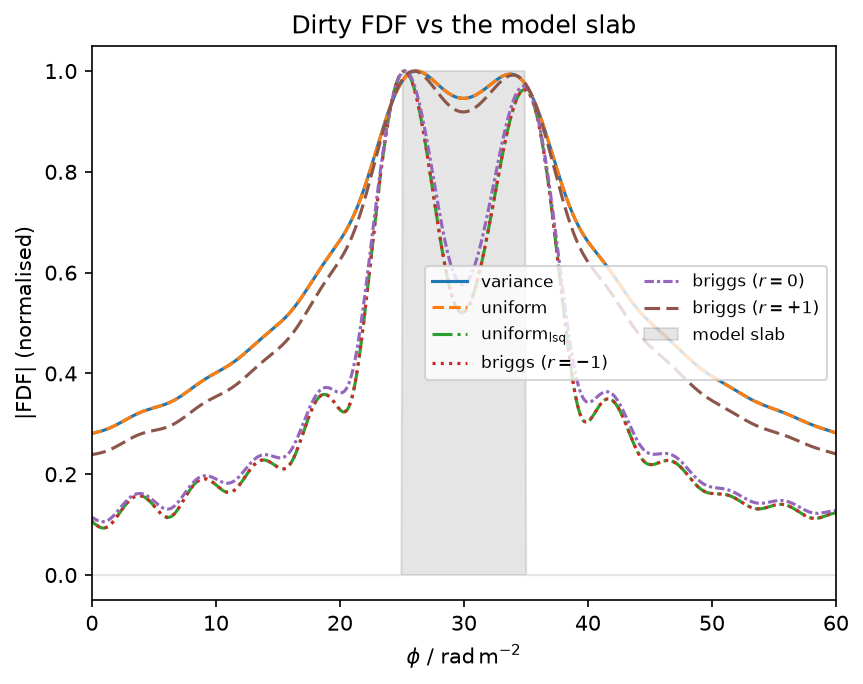

In [11]:
phi_ref = results["variance"]["phi"]
model_tophat = (np.abs(phi_ref - rm_radm2) <= delta_rm_radm2 / 2).astype(float)

fig, ax = plt.subplots()
for (label, res), ls in zip(results.items(), LINE_STYLES, strict=False):
    ax.plot(res["phi"], res["fdf"] / res["fdf"].max(), ls=ls, label=tex_label[label])
ax.fill_between(phi_ref, model_tophat, color="k", alpha=0.1, label="model slab")
ax.set(
    xlim=(0, 60),
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="|FDF| (normalised)",
    title="Dirty FDF vs the model slab",
)
ax.legend(ncol=2, fontsize="small")

### RM-CLEAN: recovered flux and the resolution/sensitivity trade

For a symmetric slab the **flux-weighted mean $\phi$** locates the source, and the
debiased zeroth moment `mom0_debias` measures the **recovered polarised flux**.
Every weighting recovers the slab centre, but the high-resolution weightings
recover *less* faint flux at a fixed threshold: resolution costs sensitivity.

weighting,mean_rm_radm2,mom0_recovered
str,f64,f64
"""variance""",30.161772,0.343495
"""uniform""",30.161772,0.343495
"""uniform_lsq""",29.99775,0.164572
"""briggs r=-1""",30.069444,0.164244
"""briggs r=0""",30.301501,0.181416
"""briggs r=+1""",30.316665,0.32473


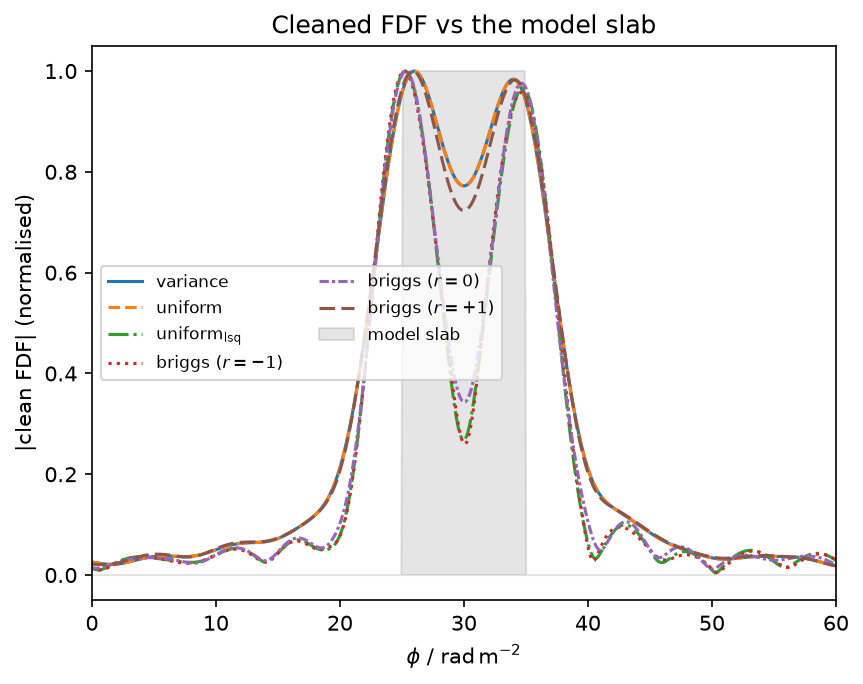

In [12]:
fig, ax = plt.subplots()
recovered_flux = {}
mean_rm = {}
cleaned = {}
with quiet_logs(logging.ERROR):
    for (label, res), ls in zip(results.items(), LINE_STYLES, strict=False):
        clean = rmclean.run_rmclean_from_synth(
            rm_synth_1d_results=res["synth"], auto_mask=8, auto_threshold=1.0
        )
        cleaned[label] = clean
        arrs = clean.fdf_arrs
        phi = arrs["phi_arr_radm2"].to_numpy()
        clean_fdf = np.abs(arrs["fdf_clean_complex_arr"].to_numpy().astype(complex))
        model = np.abs(arrs["fdf_model_complex_arr"].to_numpy().astype(complex))
        mean_rm[label] = float(np.sum(phi * model) / np.sum(model))
        recovered_flux[label] = float(clean.fdf_parameters["mom0_debias"][0])
        assert abs(mean_rm[label] - rm_radm2) < 5.0, "CLEAN recovers the slab centre"
        ax.plot(phi, clean_fdf / clean_fdf.max(), ls=ls, label=tex_label[label])
ax.fill_between(phi, model_tophat, color="k", alpha=0.1, label="model slab")
ax.set(
    xlim=(0, 60),
    xlabel=rf"$\phi$ / {u.rad / u.m**2:latex_inline}",
    ylabel="|clean FDF| (normalised)",
    title="Cleaned FDF vs the model slab",
)
ax.legend(ncol=2, fontsize="small")

assert recovered_flux["variance"] >= recovered_flux["uniform_lsq"]

pl.DataFrame(
    {
        "weighting": list(recovered_flux),
        "mean_rm_radm2": list(mean_rm.values()),
        "mom0_recovered": list(recovered_flux.values()),
    }
)

The recovered `mom0` compared with the true input polarised fraction
($\mathrm{mom0}_\mathrm{true} = f_\mathrm{pol} = 0.5$, the integrated
polarisation of the slab). Every weighting under-recovers the diffuse thick
source at this threshold, and the higher-resolution weightings recover the
least.

In [13]:
flux_table = pl.DataFrame(
    {
        "weighting": list(recovered_flux),
        "mom0_recovered": list(recovered_flux.values()),
        "mom0_true": frac_pol,
    }
).with_columns(
    (pl.col("mom0_recovered") / pl.col("mom0_true")).alias("fraction_recovered")
)
flux_table

weighting,mom0_recovered,mom0_true,fraction_recovered
str,f64,f64,f64
"""variance""",0.343495,0.5,0.68699
"""uniform""",0.343495,0.5,0.68699
"""uniform_lsq""",0.164572,0.5,0.329144
"""briggs r=-1""",0.164244,0.5,0.328488
"""briggs r=0""",0.181416,0.5,0.362833
"""briggs r=+1""",0.32473,0.5,0.649459


### Depolarisation vs slab width and the Faraday max-scale

RM-synthesis is blind to Faraday structure broader than the **max-scale**,
$\phi_\mathrm{max\text{-}scale} \approx \pi / \lambda^2_\mathrm{min}$ (set by
the shortest wavelength, i.e. the top of the band). A Burn slab thicker than this
is resolved out and depolarises. Each slab is normalised to the **same total
polarised flux** (the integral over Faraday depth), so its height scales as
$f_\mathrm{pol}/\Delta$; that total is $|P(\lambda^2{=}0)| = f_\mathrm{pol}$
in this `sinc` model, independent of width. We sweep `robust` from $-2$ to $+2$
and plot the recovered debiased `mom0` for each width. Wider slabs sit lower
(more depolarised); the dashed line is the input flux.

Faraday max-scale ~ 37 rad/m^2
Depolarisation checks passed.


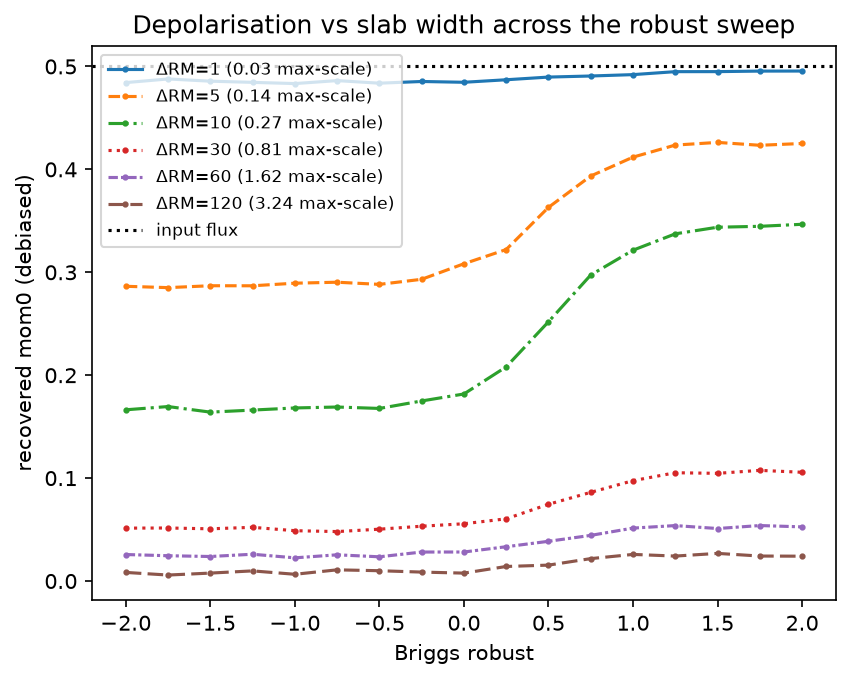

In [14]:
faraday_max_scale = float(np.pi / lambda_sq.min())
print(f"Faraday max-scale ~ {faraday_max_scale:.0f} rad/m^2")


def recover_mom0(delta_rm_radm2: float, robust: float) -> float:
    """Recovered debiased mom0 for a slab of given width and briggs robust."""
    model = faraday_slab_spectrum(
        lambda_sq, frac_pol, psi0_deg, rm_radm2, delta_rm_radm2
    )
    noisy = (
        model
        + rng.normal(0, rms_noise, freq_hz.size)
        + 1j * rng.normal(0, rms_noise, freq_hz.size)
    ).astype(np.complex128)
    err = np.ones_like(noisy) * (rms_noise + rms_noise * 1j)
    synth = rmsynth.run_rmsynth(
        freq_arr_hz=freq_hz,
        complex_pol_arr=noisy,
        complex_pol_error=err,
        n_samples=50,
        phi_max_radm2=400.0,
        weight_type="briggs",
        robust=robust,
    )
    clean = rmclean.run_rmclean_from_synth(
        rm_synth_1d_results=synth, auto_mask=8, auto_threshold=1.0
    )
    return float(clean.fdf_parameters["mom0_debias"][0])


robust_grid = np.arange(-2.0, 2.0 + 1e-6, 0.25)
slab_widths = [
    1,
    5,
    10.0,
    30.0,
    60.0,
    120.0,
]
mom0_grid = {}
with quiet_logs(logging.ERROR):  # keep the many synth/clean runs quiet
    for width in slab_widths:
        mom0_grid[width] = [recover_mom0(width, r) for r in robust_grid]

fig, ax = plt.subplots()
for (width, mom0), ls in zip(mom0_grid.items(), LINE_STYLES, strict=False):
    ax.plot(
        robust_grid,
        mom0,
        ls=ls,
        marker=".",
        ms=4,
        label=rf"$\Delta$RM={width:.0f} ({width / faraday_max_scale:.2f} max-scale)",
    )
ax.axhline(frac_pol, color="k", ls=":", label="input flux")
ax.set(
    xlabel="Briggs robust",
    ylabel="recovered mom0 (debiased)",
    title="Depolarisation vs slab width across the robust sweep",
)
ax.legend(fontsize="small", loc="upper left")

# Thin slabs are recovered; slabs wider than the max-scale depolarise away.
assert max(mom0_grid[slab_widths[0]]) > 0.6 * frac_pol, "thin slab recovered"
assert max(mom0_grid[slab_widths[-1]]) < 0.25 * frac_pol, "wide slab depolarised"
print("Depolarisation checks passed.")

RMSF resolution checks passed.


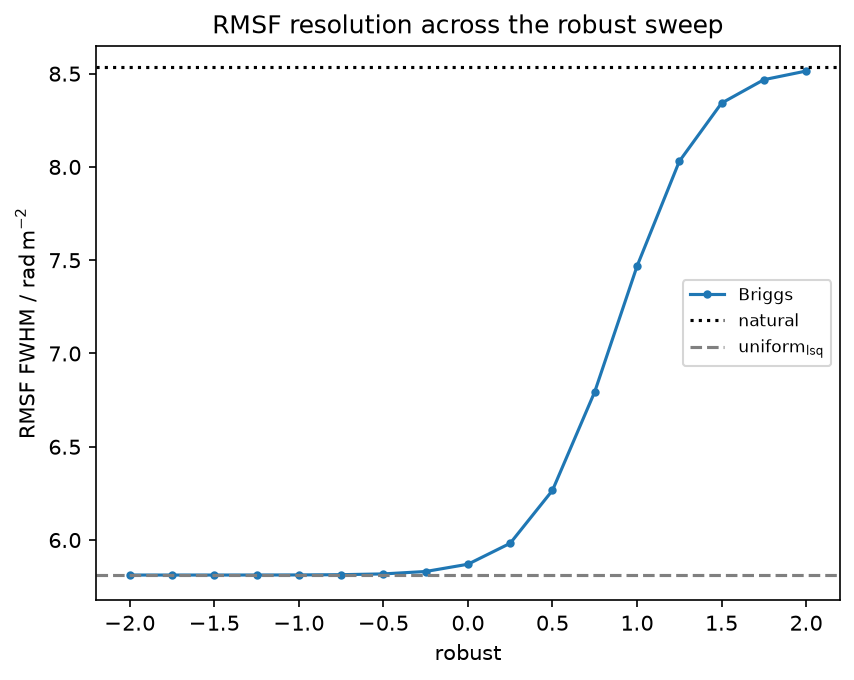

In [15]:
# RMSF resolution across the same robust sweep: FWHM moves smoothly from
# uniform_lsq (large -robust) to natural (large +robust), flattening by |r|~2.
with quiet_logs(logging.ERROR):
    robust_fwhm = [
        run_weighting(weight_type="briggs", robust=r)["fwhm"] for r in robust_grid
    ]

fwhm_natural = results["variance"]["fwhm"]
fwhm_lsq = results["uniform_lsq"]["fwhm"]

fig, ax = plt.subplots()
ax.plot(robust_grid, robust_fwhm, ".-", label="Briggs")
ax.axhline(fwhm_natural, color="k", ls=":", label="natural")
ax.axhline(fwhm_lsq, color="grey", ls="--", label=r"uniform$_\mathrm{lsq}$")
ax.set(
    xlabel="robust",
    ylabel=rf"RMSF FWHM / {u.rad / u.m**2:latex_inline}",
    title="RMSF resolution across the robust sweep",
)
ax.legend(fontsize="small")

# Higher robust -> wider RMSF (less resolution); +/-2 reach the endpoints.
assert robust_fwhm[-1] >= robust_fwhm[0], "higher robust is wider"
assert abs(robust_fwhm[0] - fwhm_lsq) < 0.5, "r=-2 approximates uniform_lsq"
assert abs(robust_fwhm[-1] - fwhm_natural) < 0.5, "r=+2 approximates natural"
print("RMSF resolution checks passed.")

### Extrapolating each clean model back to $\lambda^2 = 0$

Inverse RM-synthesis turns each clean model FDF back into $Q/U$ over $\lambda^2$.
On a contiguous grid from $0$ (the intrinsic, unrotated polarisation) to the band
maximum, comparing with the true model shows: **in band** the reconstruction
tracks the model for every weighting (to within the noise); **at $\lambda^2 =
0$**, well outside the band, a Faraday-thick model is unconstrained and diverges
from the truth.

variance     in-band reconstruction RMS = 0.0086
uniform      in-band reconstruction RMS = 0.0086
uniform_lsq  in-band reconstruction RMS = 0.0130
briggs r=-1  in-band reconstruction RMS = 0.0122
briggs r=0   in-band reconstruction RMS = 0.0118
briggs r=+1  in-band reconstruction RMS = 0.0082
Extrapolation checks passed.


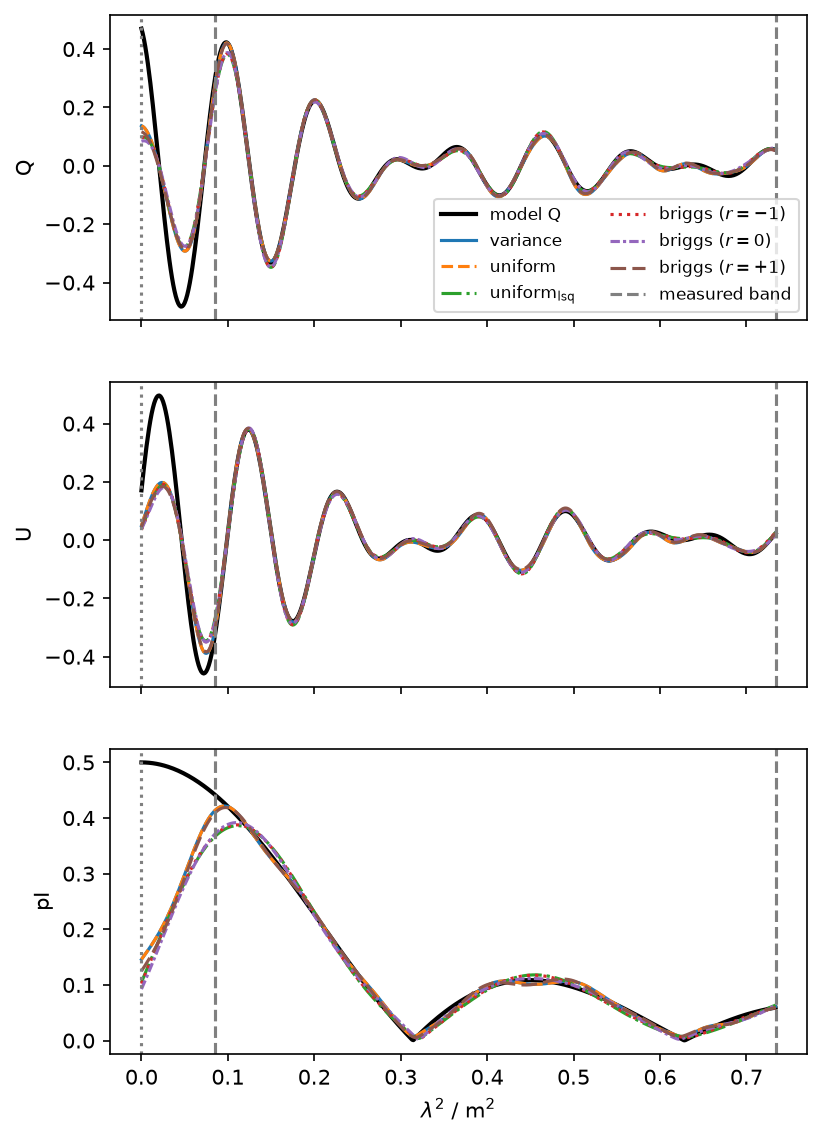

In [16]:
# Contiguous lambda^2 grid from 0 to the band maximum (the observed samples
# are irregular; a dense grid gives smooth reconstruction curves).
lambda_sq_ext = np.linspace(0.0, lambda_sq.max(), 500)
model_ext = faraday_slab_spectrum(lambda_sq_ext, **model_kw)
in_band = (lambda_sq_ext >= lambda_sq.min()) & (lambda_sq_ext <= lambda_sq.max())

fig, (ax0, ax1, ax2) = plt.subplots(3, 1, sharex=True, figsize=(6, 9))
ax0.plot(lambda_sq_ext, model_ext.real, "k", lw=2, label="model Q")
ax1.plot(lambda_sq_ext, model_ext.imag, "k", lw=2, label="model U")
ax2.plot(lambda_sq_ext, np.abs(model_ext), "k", lw=2, label="model pI")
band_rms = {}
with quiet_logs(logging.ERROR):
    for (label, clean), ls in zip(cleaned.items(), LINE_STYLES, strict=False):
        arrs = clean.fdf_arrs
        phi = arrs["phi_arr_radm2"].to_numpy()
        fdf_model = arrs["fdf_model_complex_arr"].to_numpy().astype(complex)
        lam0 = float(clean.fdf_parameters["lam_sq_0_m2"][0])
        recon = inverse_rmsynth_nufft(fdf_model, lambda_sq_ext, phi, lam0)
        band_rms[label] = float(
            np.sqrt(np.mean(np.abs(recon[in_band] - model_ext[in_band]) ** 2))
        )
        ax0.plot(lambda_sq_ext, recon.real, ls=ls, label=tex_label[label])
        ax1.plot(lambda_sq_ext, recon.imag, ls=ls, label=tex_label[label])
        ax2.plot(lambda_sq_ext, np.abs(recon), ls=ls, label=tex_label[label])
        print(f"{label:12s} in-band reconstruction RMS = {band_rms[label]:.4f}")
ax0.axvline(0.0, color="grey", ls=":")
ax1.axvline(0.0, color="grey", ls=":")
ax2.axvline(0.0, color="grey", ls=":")

for i, ax in enumerate((ax0, ax1, ax2)):
    ax.axvline(
        lambda_sq.min(),
        color="grey",
        ls="--",
        label="measured band" if i == 0 else None,
    )
    ax.axvline(lambda_sq.max(), color="grey", ls="--")

ax0.set(ylabel="Q")
ax1.set(ylabel="U")
ax2.set(xlabel=rf"$\lambda^2$ / {u.m**2:latex_inline}", ylabel="pI")
ax0.legend(ncol=2, fontsize="small")

# Every weighting reconstructs the in-band spectrum to within the noise.
for label, rms in band_rms.items():
    assert rms < 3 * rms_noise, f"{label} in-band reconstruction diverges"
print("Extrapolation checks passed.")

## Summary

- `briggs` tunes continuously between `natural` (max sensitivity) and
  `uniform_lsq` (max resolution); narrower-RMSF weightings recover less faint flux
  and reconstruct the spectrum slightly worse.
- `uniform_lsq` is interferometric **uniform** weighting on the $\lambda^2$ grid:
  each channel is weighted by the inverse local density (per-cell natural-weight
  occupancy over the cell width), so each occupied cell contributes equally and
  channels sharing a cell get one weight. The weight steps where the true
  sampling density changes (gaps, channelisation) - correct inverse-density
  weighting, not aliasing. The resolution gain is coverage-dependent (large on
  the wide GMIMS band, above).
- Extrapolating a clean model to $\lambda^2 = 0$ is reliable only within the
  observed band; a Faraday-thick source is unconstrained beyond it.
- **Weighting does not correct an uncorrected Stokes $I$ spectrum.** It reshapes
  the RMSF but cannot remove the multiplicative $I(\lambda^2)$ that biases the
  effective RMSF; divide out Stokes $I$ (fractional polarisation) for that.